## XMAC02 - Atividade Avaliativa 1
### Nome:
### Nro Matric:

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Nas questões de 1 a 4 você deve utilizar o dataset nba2k.csv.

In [3]:
df = pd.read_csv('nba2k.csv')
df.head()

,Unnamed: 0,full_name,rating,jersey,team,position,b_day,height,weight,salary,country,draft_year,draft_round,draft_peak,college,version
0,0,LeBron James,97,#23,Los Angeles Lakers,F,12/30/84,2.06,113.4,37436858,USA,2003,1,1,NaN,NBA2k20
1,1,Kawhi Leonard,97,#2,Los Angeles Clippers,F,06/29/91,2.01,102.1,32742000,USA,2011,1,15,San Diego State,NBA2k20
2,2,Giannis Antetokounmpo,96,#34,Milwaukee Bucks,F-G,12/06/94,2.11,109.8,25842697,Greece,2013,1,15,NaN,NBA2k20
3,3,Kevin Durant,96,#7,Brooklyn Nets,F,09/29/88,2.08,104.3,37199000,USA,2007,1,2,Texas,NBA2k20
4,4,James Harden,96,#13,Houston Rockets,G,08/26/89,1.96,99.8,38199000,USA,2009,1,3,Arizona State,NBA2k20


### Questão 1 [valor: 0,5 pt]
Obtenha a média, o desvio padrão e a mediana da altura dos armadores (position = G) estrangeiros da NBA, ou seja, dos jogadores que jogam na posição de armador e que tenham country diferente de USA.

In [5]:
media = df[df['position'] == 'G']['height'].mean()
desvio = df[df['position'] == 'G']['height'].std()
mediana = df[df['position'] == 'G']['height'].mean()
print(media)
print(desvio)
print(mediana)

1.918224852071006
0.053722581911796165
1.918224852071006


### Questão 2 [valor: 1,0 pt]
Gere um gráfico contendo dois boxplots comparando o salário dos jogoadores do Los Angeles Lakers e do Utah Jazz.

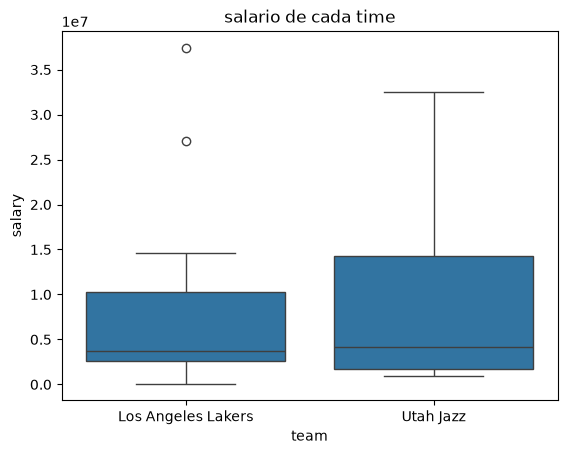

In [6]:
times = ['Los Angeles Lakers', 'Utah Jazz']
df3 = df[df['team'].isin(times)]
sns.boxplot(data=df3, x='team', y = 'salary')
plt.title('salario de cada time')
plt.show()

### Questão 3 [valor: 1,5 pt]
Gere um gráfico que exiba o valor do salário dos 10 jogadores mais altos da NBA, organizados de ordem descendente, ou seja, do mais bem pago para o menos bem pago.

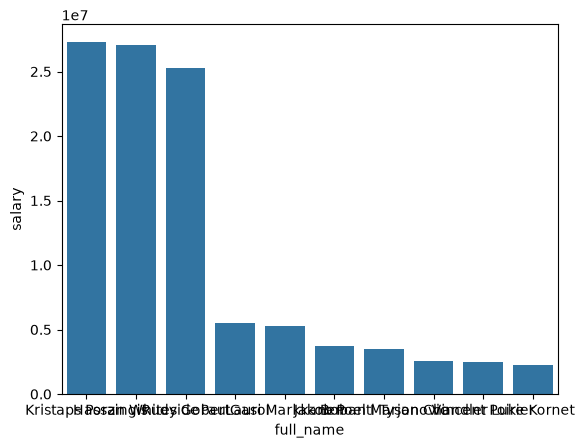

In [ ]:
dfAltura = df.sort_values('height', ascending=False).head(10)
dfSalario = dfAltura.sort_values('salary', ascending= False)
sns.barplot(data = dfSalario, x = 'full_name', y = 'salary')
plt.show()


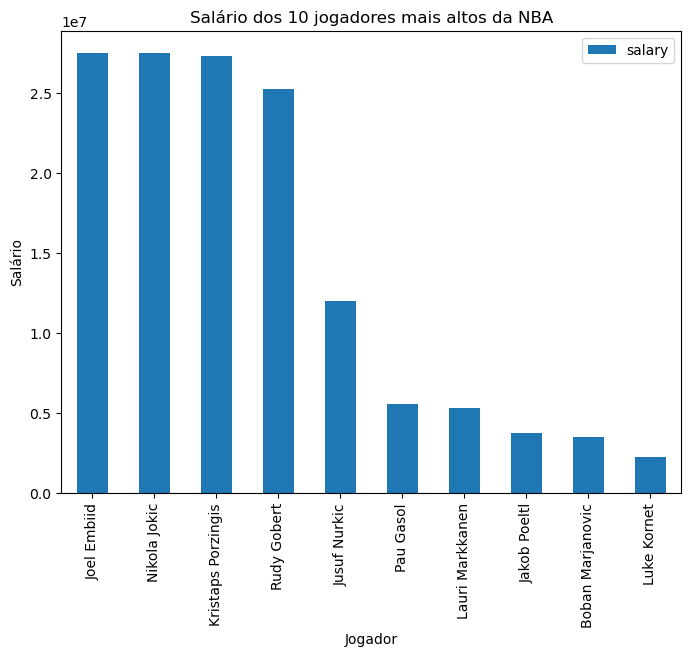

### Questão 4 [valor: 2,0 pts]
Gere dois gráficos de pizza lado a lado que exibam: \
A) o percentual de jogadores americanos vs jogadores estrangeiros na NBA; \
B) o valor total pago a jogadores americanos vs jogadores estrangeiros na NBA.

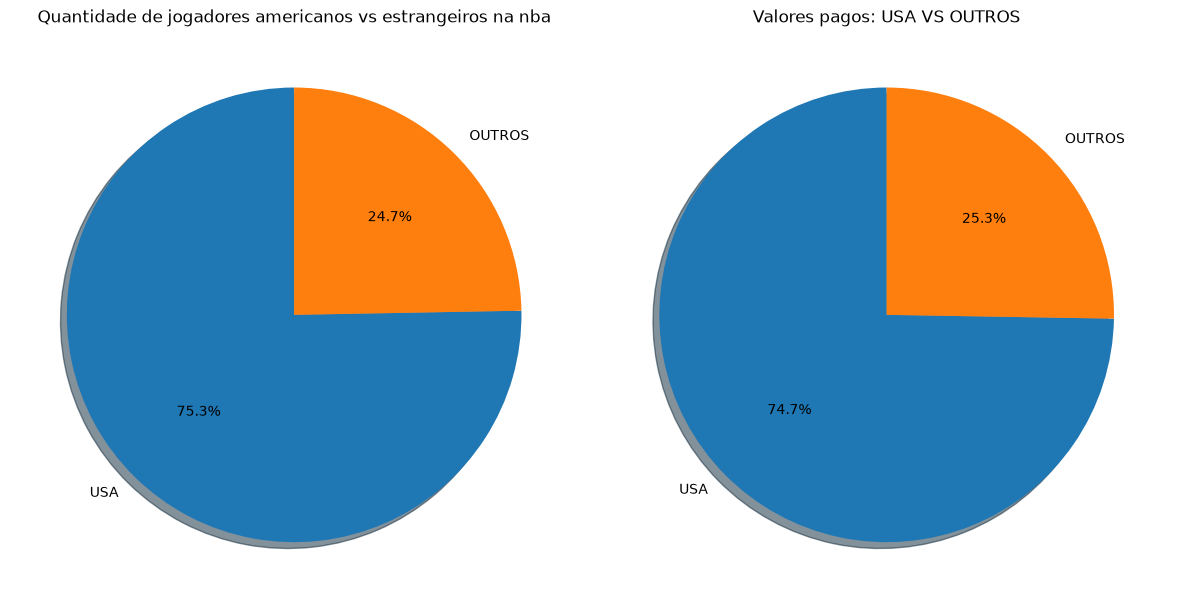

In [14]:
dfUSA = df[df['country'] == 'USA']
dfOutros = df[df['country'] != 'USA']

sizesUSA = dfUSA['full_name'].count()
sizesOutros = dfOutros['full_name'].count()

sizesSalUSA = dfUSA['salary'].sum()
sizesSalOutros = dfOutros['salary'].sum()

labels = ['USA', 'OUTROS']

plt.rcParams['figure.figsize'] = [12, 6]
plt.subplot(1, 2, 1)
plt.pie([sizesUSA, sizesOutros], labels=labels, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Quantidade de jogadores americanos vs estrangeiros na nba')
plt.subplot(1, 2, 2)
plt.pie([sizesSalUSA, sizesSalOutros], labels=labels, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Valores pagos: USA VS OUTROS')
plt.tight_layout()
plt.show()



Nas questões de 5 a 8 deve-se usar os dataframes a seguir.

In [16]:
bike_day = pd.read_csv('day.csv')
students = pd.read_csv('student-por.csv', sep=';')

print('Bike — dados diários:', bike_day.shape)
print('Desempenho estudantil:', students.shape)
bike_day.head()

Bike — dados diários: (731, 16)
Desempenho estudantil: (649, 33)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Questão 5 [valor: 1,5]

Utilize o DataFrame `bike_day`. Plote um gráfico de barras que mostre a média diária de locações de bike por estação. Substitua os códigos numéricos pelos nomes **Primavera**, **Verão**, **Outono** e **Inverno**

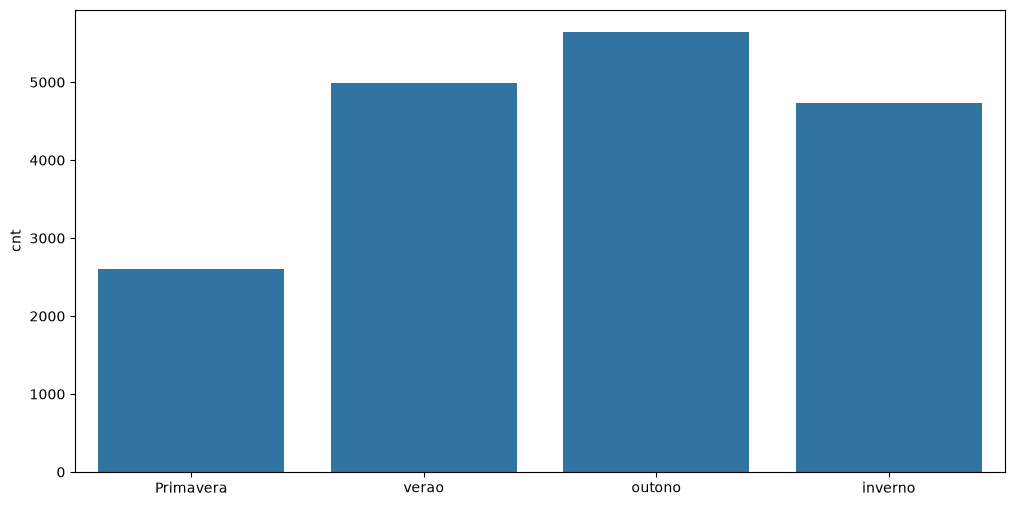

In [30]:
sizes = [1, 2, 3, 4]
labels = ['Primavera', 'verao', 'outono', 'inverno']

media = bike_day.groupby('season')['cnt'].mean()

sns.barplot(x = labels, y= media)
plt.show()


### Questão 6 [valor: 1,0]

Utilize o DataFrame `students`.

1. Agrupe os estudantes pela categoria de tempo semanal de estudo (`studytime`).
2. Para cada categoria, obtenha:
   - a quantidade de estudantes;
   - a média da nota final (`G3`);
3. Armazene as duas medidas em um novo DataFrame com nomes de colunas claros.
4. Construa um **gráfico de linha** da média de `G3` em função da categoria de tempo de estudo.

In [42]:
students.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


### Questão 7 [valor: 1,0]

Utilize o DataFrame `students`. Construa um gráfico de barras agrupado por sexo que mostre a quantidade de alunos com e sem Internet em casa.

<Axes: xlabel='sex', ylabel='count'>

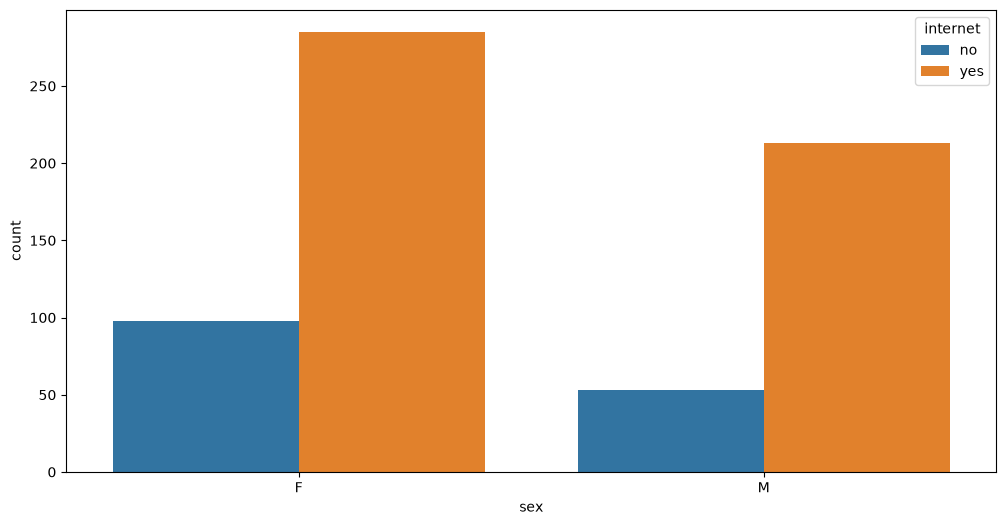

In [49]:
sns.countplot(data = students, x = 'sex', hue= 'internet')

## Questão 8 [valor: 1,5]

Utilize o DataFrame `students`.

1. Investigue a relação entre tempo semanal de estudo (`studytime`) e intenção de cursar o ensino superior (`higher`).
2. Construa uma tabela de contingência **normalizada por linha**: cada linha deverá mostrar as proporções de respostas `yes` e `no` dentro daquela categoria de tempo de estudo.
3. Exiba os valores como percentuais, arredondados para uma casa decimal.
4. Construa um **gráfico de barras empilhadas**.
5. Escreva uma interpretação breve dos resultados.

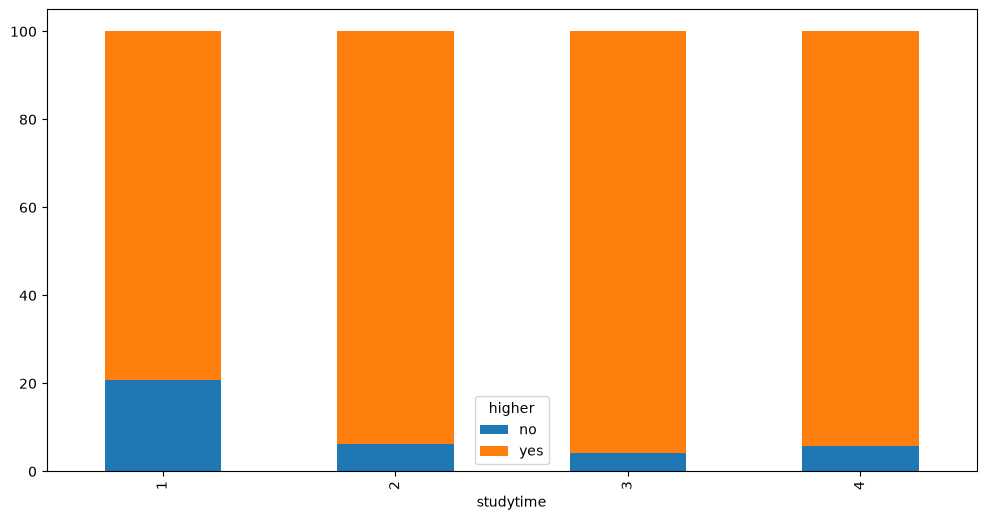

In [53]:
tabela = pd.crosstab(
    students['studytime'],
    students['higher'],
    normalize = 'index'
)

tabela = tabela * 100

tabela.plot(kind= 'bar', stacked= True)
plt.show()